In [2]:
import scanpy as sc
import pandas as pd
from pathlib import Path

sc.settings.verbosity = 1

# Map each sample folder to its subtype
samples = {
    "ER_MH0001": "ER+",
    "ER_MH0042": "ER+",
    "TN_MH0126": "TNBC",
    "TN_MH0135": "TNBC",
}

raw = Path("data/raw")
adatas = []
for sample_id, subtype in samples.items():
    a = sc.read_10x_mtx(raw / sample_id, var_names="gene_symbols")
    a.obs["sample"] = sample_id          # which patient
    a.obs["subtype"] = subtype           # ER+ or TNBC
    a.obs_names = [f"{sample_id}_{bc}" for bc in a.obs_names]  # unique cell names
    adatas.append(a)
    print(f"{sample_id}: {a.n_obs} cells, {a.n_vars} genes")

/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


ER_MH0001: 7375 cells, 33538 genes
ER_MH0042: 5439 cells, 33538 genes
TN_MH0126: 3666 cells, 33538 genes
TN_MH0135: 15870 cells, 33538 genes


In [3]:
# Concatenate all four samples into one object
adata = sc.concat(adatas, join="outer")
adata.obs_names_make_unique()
print(f"Combined: {adata.n_obs} cells, {adata.n_vars} genes\n")

# Flag mitochondrial genes — THE verification step
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")

Combined: 32350 cells, 33538 genes

Mitochondrial genes found: 13


In [4]:
# Compute QC metrics per cell
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=False)

# Peek at the distributions
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,32350.000000,32350.000000,32350.000000
mean,1396.404730,4177.814941,5.388002
std,962.122327,4552.675781,5.376399
min,17.000000,500.000000,0.000000
25%,625.000000,1399.000000,3.084331
50%,1180.000000,2935.000000,4.457652
75%,1919.000000,5408.750000,6.151206
max,8526.000000,88509.000000,97.662979


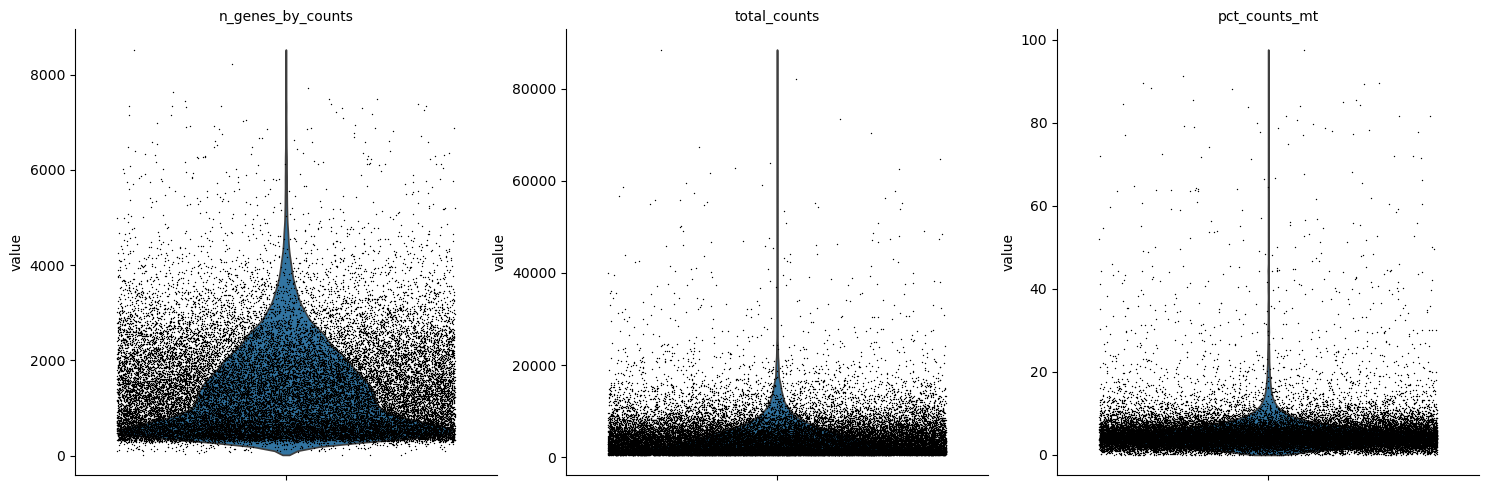

In [5]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             jitter=0.4, multi_panel=True)

In [6]:
n_before = adata.n_obs

# Filter genes seen in too few cells, then filter cells
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["n_genes_by_counts"] >= 200]
adata = adata[adata.obs["n_genes_by_counts"] <= 6000]
adata = adata[adata.obs["pct_counts_mt"] < 15].copy()

print(f"Cells: {n_before} → {adata.n_obs}  (removed {n_before - adata.n_obs})")
print(adata.obs["subtype"].value_counts())

Cells: 32350 → 31357  (removed 993)
subtype
TNBC    18790
ER+     12567
Name: count, dtype: int64


In [7]:
# Run scrublet per sample — it predicts doublets within each
sc.pp.scrublet(adata, batch_key="sample")

print(f"Predicted doublets: {adata.obs['predicted_doublet'].sum()}")
print(adata.obs["predicted_doublet"].value_counts())

Predicted doublets: 92
predicted_doublet
False    31265
True        92
Name: count, dtype: int64


In [8]:
# Remove the predicted doublets
adata = adata[~adata.obs["predicted_doublet"]].copy()
print(f"Final clean cells: {adata.n_obs}")
print(adata.obs.groupby("subtype")["sample"].value_counts())

Final clean cells: 31265
subtype  sample   
ER+      ER_MH0001     7259
         ER_MH0042     5217
TNBC     TN_MH0135    15345
         TN_MH0126     3444
Name: count, dtype: int64


In [9]:
from pathlib import Path
Path("data/processed").mkdir(parents=True, exist_ok=True)
adata.write("data/processed/01_qc_filtered.h5ad")
import os; print("Exists:", os.path.exists("data/processed/01_qc_filtered.h5ad"))

Exists: True
